# GPT-5.4-mini Attention Head Analysis

Note: this code was tested in Google Colab using a High-RAM A100 GPU, and has not been verified in any other scenarios

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)
# roberta_dir = "/content/drive/MyDrive/Colab Notebooks/NLU_project/gpt-5-4-mini-roberta-classifier"

Mounted at /content/drive


In [ ]:
import gdown

# Download the saved GPT-5.4-mini RoBERTa model from the shared drive link
gpt_5_4_mini_roberta_url = 'https://drive.google.com/drive/folders/1Qxhx0VB9G01PQ_F83x2kPTGY7ucdwYCB?usp=sharing'
gdown.download_folder(gpt_5_4_mini_roberta_url, quiet=False, use_cookies=False, remaining_ok=True)
roberta_dir = "./gpt-5-4-mini-roberta-classifier"

In [ ]:
# Download the test data from GitHub
!wget https://raw.githubusercontent.com/Lennart-Martens/Explaining-Uncanny-Text/refs/heads/main/Processed_GPT5.4-mini_Data/test.csv

In [ ]:
import torch
import torch.nn.functional as F
from transformers import RobertaForSequenceClassification, RobertaTokenizer

model = RobertaForSequenceClassification.from_pretrained(
    roberta_dir,
    output_attentions=True,
)
tokenizer = RobertaTokenizer.from_pretrained(roberta_dir)

model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
from datasets import load_dataset

dataset = load_dataset("csv", data_files={
    "test": "./test.csv",
})

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=512,
    )

tokenized = dataset.map(tokenize, batched=True, remove_columns=dataset["test"].column_names)
tokenized.set_format("torch", columns=["input_ids", "attention_mask"])

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/11080 [00:00<?, ? examples/s]

In [4]:
def get_confidence(inputs):
    with torch.no_grad():
        logits = model(**inputs).logits
    return F.softmax(logits, dim=-1).max().item()

def ablate_head(model, layer, head):
    # Zero out a specific head's output
    def hook_fn(module, input, output):
        context, *rest = output  # unpack — context is (batch, seq_len, hidden_size)
        head_size = context.shape[-1] // 12
        context = context.clone()
        context[:, :, head * head_size:(head + 1) * head_size] = 0
        return (context, *rest)  # repack the tuple before returning

    layer_module = model.roberta.encoder.layer[layer].attention.self
    hook = layer_module.register_forward_hook(hook_fn)
    return hook

In [ ]:
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm

def run_ablation_on_dataset(model, tokenizer, dataset, num_layers=12, num_heads=12, batch_size=64):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    head_drops = np.zeros((num_layers, num_heads))
    dataloader = DataLoader(dataset, batch_size=batch_size)

    for batch in tqdm(dataloader, desc="Running ablation"):
        inputs = {
            "input_ids": batch["input_ids"].to(device),
            "attention_mask": batch["attention_mask"].to(device),
        }

        with torch.no_grad():
            logits = model(**inputs).logits
        baselines = F.softmax(logits, dim=-1).max(dim=-1).values

        for layer in range(num_layers):
            for head in range(num_heads):
                hook = ablate_head(model, layer, head)
                with torch.no_grad():
                    ablated_logits = model(**inputs).logits
                hook.remove()

                ablated_conf = F.softmax(ablated_logits, dim=-1).max(dim=-1).values
                drop = (baselines - ablated_conf).mean().item()
                head_drops[layer, head] += drop

    head_drops /= len(dataloader)
    return head_drops

In [ ]:
# Run the ablation on the full test set
head_drops = run_ablation_on_dataset(model, tokenizer, tokenized["test"])


# If this appears to be taking too long, can run the next cell instead, 
# the heat map and top heads might be slightly different but the bar
# charts should be pretty similar

In [ ]:
# import random

# # Run the ablation on a random selection of the test set instead to save time

# test_size = len(tokenized["test"])
# subset_size = test_size // 8

# random.seed(27)
# indices = random.sample(range(test_size), subset_size)
# subset = tokenized["test"].select(indices)

# head_drops = run_ablation_on_dataset(model, tokenizer, subset)

In [ ]:
# Print ranked results
print("Most important heads averaged across test set:")
indexed = [((l, h), head_drops[l, h]) for l in range(12) for h in range(12)]
ranked = sorted(indexed, key=lambda x: x[1], reverse=True)
for (layer, head), drop in ranked[:10]:
    print(f"  Layer {layer:>2}, Head {head:>2}: avg confidence drop = {drop:.8f}")

Running ablation: 100%|██████████| 44/44 [43:04<00:00, 58.73s/it]

Most important heads averaged across test set:
  Layer  6, Head  1: avg confidence drop = 0.00114751
  Layer  5, Head  2: avg confidence drop = 0.00057312
  Layer  4, Head  8: avg confidence drop = 0.00029786
  Layer  3, Head 11: avg confidence drop = 0.00027784
  Layer  2, Head 11: avg confidence drop = 0.00025546
  Layer  3, Head  2: avg confidence drop = 0.00024488
  Layer  2, Head  9: avg confidence drop = 0.00018407
  Layer  3, Head  9: avg confidence drop = 0.00017568
  Layer  4, Head  7: avg confidence drop = 0.00016972
  Layer  4, Head  3: avg confidence drop = 0.00015307


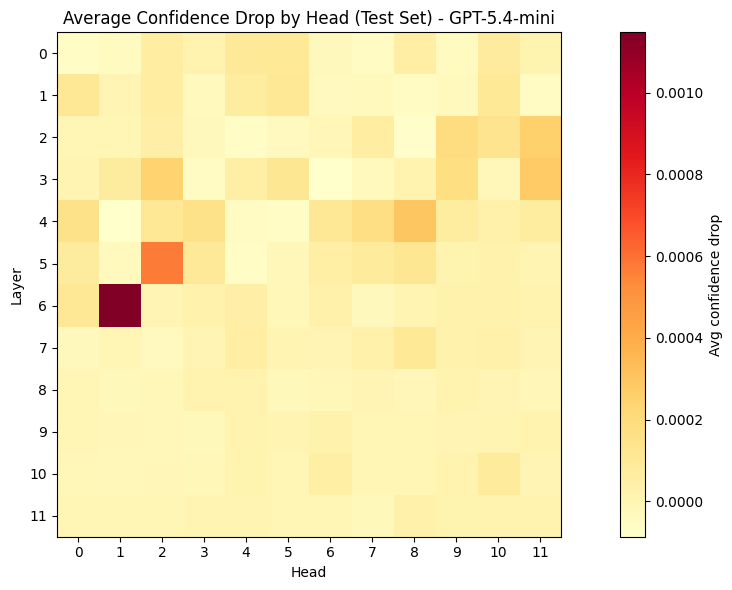

In [ ]:
# Plot the Heat Map of the Avg Confidence Drop by Head
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(head_drops, cmap="YlOrRd")

ax.set_xlabel("Head")
ax.set_ylabel("Layer")
ax.set_xticks(range(12))
ax.set_yticks(range(12))
ax.set_title("Average Confidence Drop by Head (Test Set) - GPT-5.4-mini")
plt.colorbar(im, label="Avg confidence drop")
plt.tight_layout()
plt.show()

In [ ]:
from transformers import RobertaModel

# Attention head analysis needs the base model, not the classifier
base_model = RobertaModel.from_pretrained(
    roberta_dir,
    output_attentions=True,
)
tokenizer = RobertaTokenizer.from_pretrained(roberta_dir)
base_model.eval()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: /content/drive/MyDrive/Colab Notebooks/NLU_project/gpt-5-4-mini-roberta-classifier
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.weight    | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
pooler.dense.weight        | MISSING    | 
pooler.dense.bias          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropou

In [ ]:
import string

def plot_top_tokens(outputs, tokens, layer, head, top_k=20, filter_punct=True):
    # Get <s> token's attention row
    attn = outputs.attentions[layer][0, head, 0, :]

    # Filter out punctuation and special tokens
    if filter_punct:
      skip = {"<s>", "</s>", "<pad>"}
      mask = torch.tensor([
          t.replace("Ġ", "") not in skip and
          not all(c in string.punctuation for c in t.replace("Ġ", ""))
          for t in tokens
      ])
      filtered_attn = attn.clone()
      filtered_attn[~mask] = 0
    else:
      filtered_attn = attn.clone()

    # Get top k tokens by attention weight
    top_scores, top_indices = filtered_attn.topk(top_k)
    top_tokens = [tokens[i] for i in top_indices]
    top_scores = top_scores.detach().numpy()

    # Plot the Bar Chart
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(top_k), top_scores, color="steelblue")
    ax.set_yticks(range(top_k))
    ax.set_yticklabels([t.replace("Ġ", " ") for t in top_tokens])
    ax.invert_yaxis()
    ax.set_xlabel("Attention Weight")
    ax.set_title(f"Top {top_k} content tokens attended to by <s> — Layer {layer}, Head {head}")
    plt.tight_layout()
    plt.show()

In [ ]:
# Get the output for an LLM example

llm_text = dataset["test"][6000]["text"]
print(llm_text)

llm_inputs = tokenizer(llm_text, return_tensors="pt")
llm_tokens = tokenizer.convert_ids_to_tokens(llm_inputs["input_ids"][0])

with torch.no_grad():
    llm_outputs = base_model(**llm_inputs)

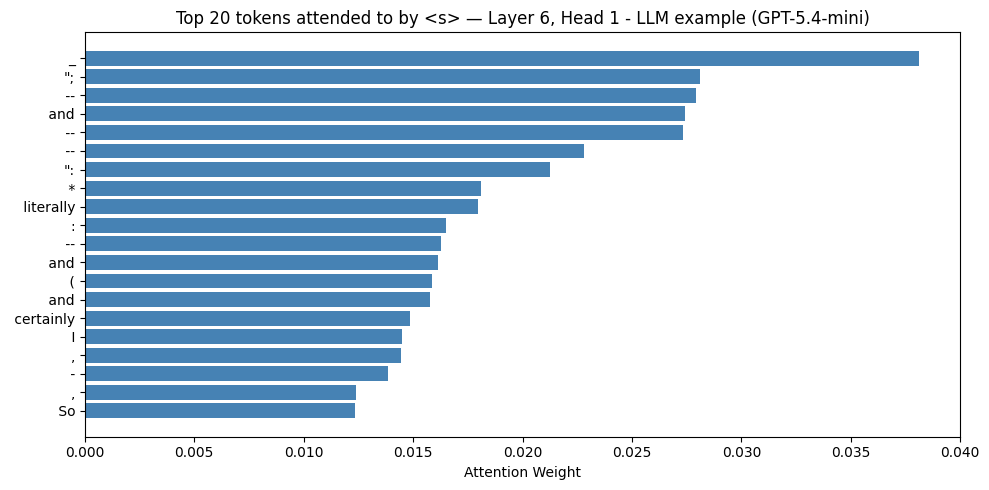

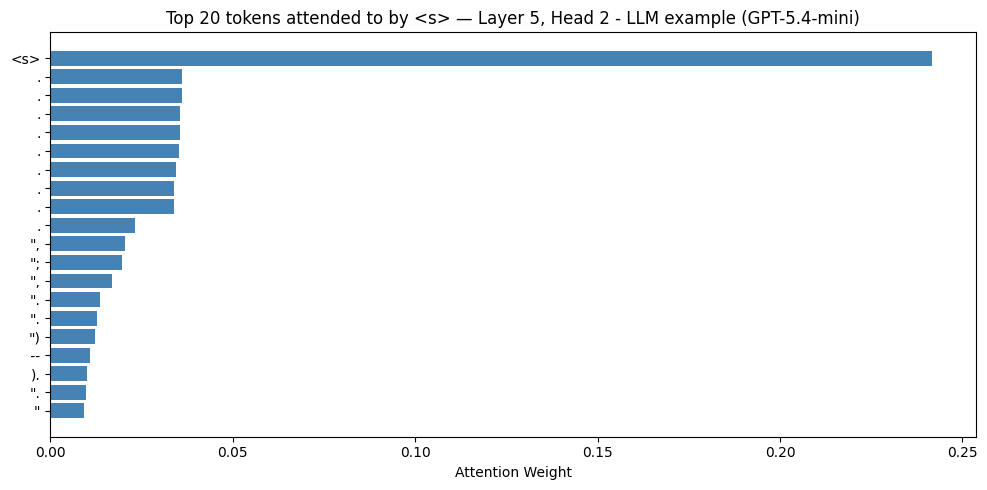

In [ ]:
# Plot the LLM example (including punctuation)
plot_top_tokens(llm_outputs, llm_tokens, layer=6, head=1, top_k=20, filter_punct=False)
plot_top_tokens(llm_outputs, llm_tokens, layer=5, head=2, top_k=20, filter_punct=False)

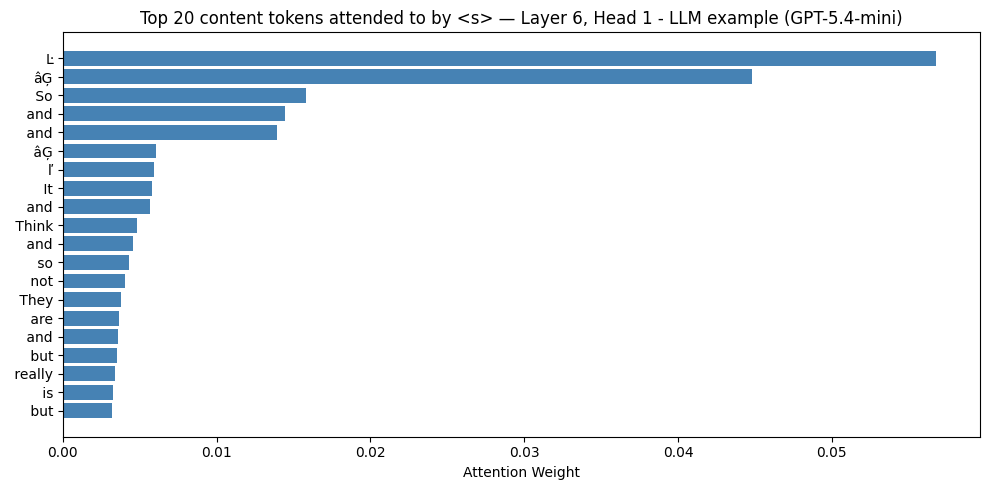

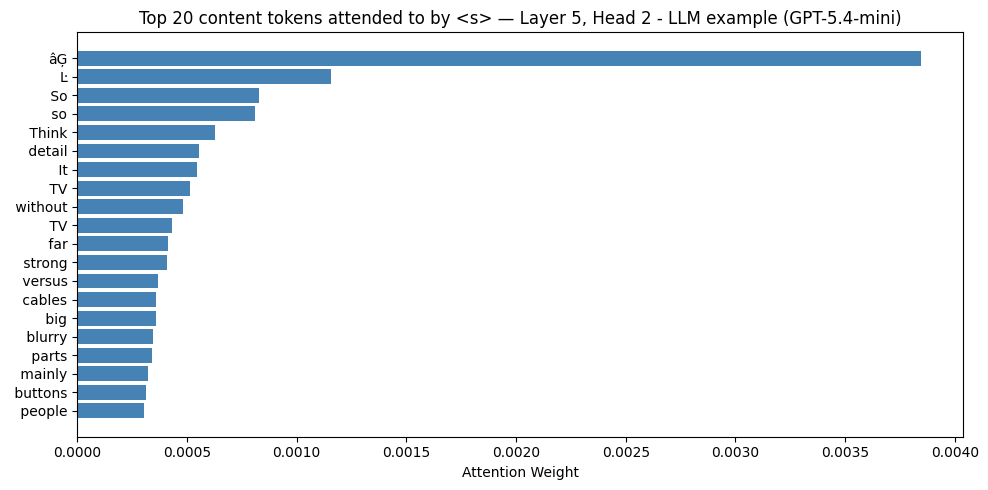

In [ ]:
# Plot the LLM example (without punctuation)
plot_top_tokens(llm_outputs, llm_tokens, layer=6, head=1, top_k=20)
plot_top_tokens(llm_outputs, llm_tokens, layer=5, head=2, top_k=20)

In [ ]:
# Get the output for a human example

human_text = dataset["test"][4200]["text"]
print(human_text)

human_inputs = tokenizer(human_text, return_tensors="pt")
human_tokens = tokenizer.convert_ids_to_tokens(human_inputs["input_ids"][0])

with torch.no_grad():
    human_outputs = base_model(**human_inputs)

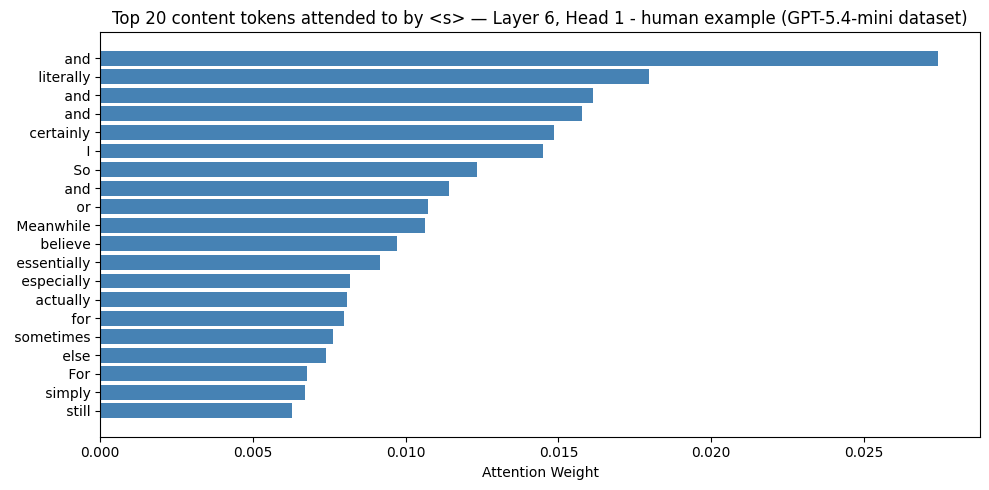

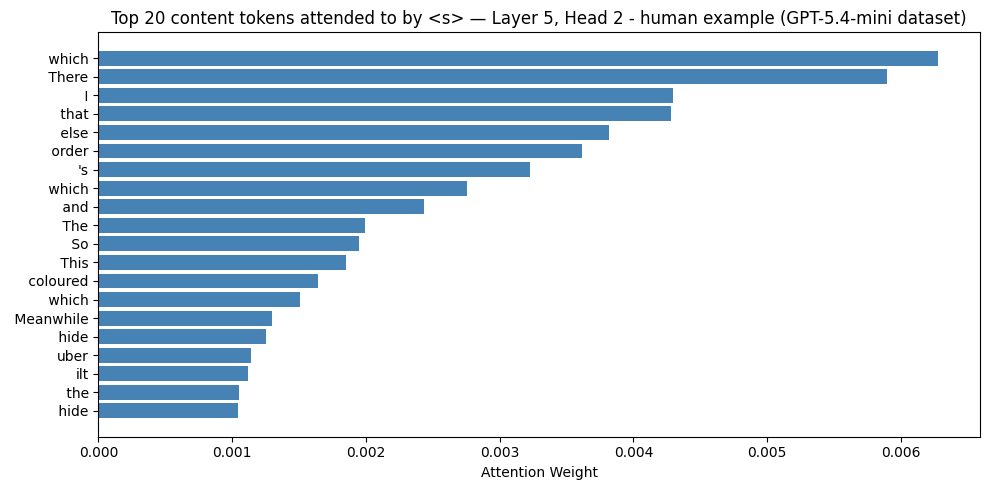

In [ ]:
# Results from a human example (punctuation excluded)

plot_top_tokens(human_outputs, human_tokens, layer=6, head=1, top_k=20)
plot_top_tokens(human_outputs, human_tokens, layer=5, head=2, top_k=20)